# Regime-aware SHAP on electricity demand

This is the second `regime-shap` example, in a deliberately different domain from the first.
The finance notebook asked whether a volatility model's drivers survive a market crisis. Here
we ask a calmer question of a very different system: do the drivers of Great Britain's daily
electricity demand stay the same through the turning seasons, or does the model lean on
different features in winter than in summer?

It also shows two things the finance notebook did not:

1. **Hand-labelled regimes.** Instead of letting the package find break points, we label each
   day by its season directly, which is the other regime-input path `regime_shap` supports.
2. **A small regime, read with bootstrap confidence intervals.** Alongside the four seasons we
   carve out the spring 2020 COVID lockdown, a genuine structural break in demand, and because
   it is short we read its stability with bootstrap intervals rather than a single number.

## The data

Great Britain historic electricity demand from NESO (the National Energy System Operator),
public and free to reuse under the NESO Open Data Licence, no API key. NESO publish one
half-hourly file per year; we aggregate the 48 daily settlement periods to daily figures and
bundle a small snapshot (2016 to 2023) under `data/gb_electricity_demand.csv`.

| Column | Meaning |
| --- | --- |
| `demand_mean` | Mean national demand across the day, MW |
| `demand_peak` | Peak national demand in the day, MW |
| `wind` | Mean embedded (distribution-connected) wind generation, MW |
| `solar` | Mean embedded solar generation, MW |

For transparency, this is how the snapshot was built, using only the public CKAN API:

```python
import json, urllib.request
import pandas as pd

pkg = json.load(urllib.request.urlopen(
    "https://api.neso.energy/api/3/action/package_show?id=historic-demand-data"))
# each year is one CSV resource; download 2016..2023, then for each file:
#   group the 48 half-hourly SETTLEMENT_PERIOD rows by SETTLEMENT_DATE and take
#   the mean/max of ND and the mean of EMBEDDED_WIND_GENERATION / EMBEDDED_SOLAR_GENERATION
```

In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

from regime_shap import RegimeSHAPAnalyzer

%matplotlib inline

In [2]:
raw = pd.read_csv("data/gb_electricity_demand.csv", parse_dates=["date"]).set_index("date")
print(f"{len(raw):,} days, {raw.index.min().date()} to {raw.index.max().date()}")
raw.head()

2,922 days, 2016-01-01 to 2023-12-31


,demand_mean,demand_peak,wind,solar
date,,,,
2016-01-01,29360.0,37511,2049.1,131.6
2016-01-02,30071.0,40880,2261.9,95.7
2016-01-03,30849.3,41764,2155.2,86.6
2016-01-04,36097.9,46917,1784.5,223.1
2016-01-05,37103.5,47656,1436.2,215.5


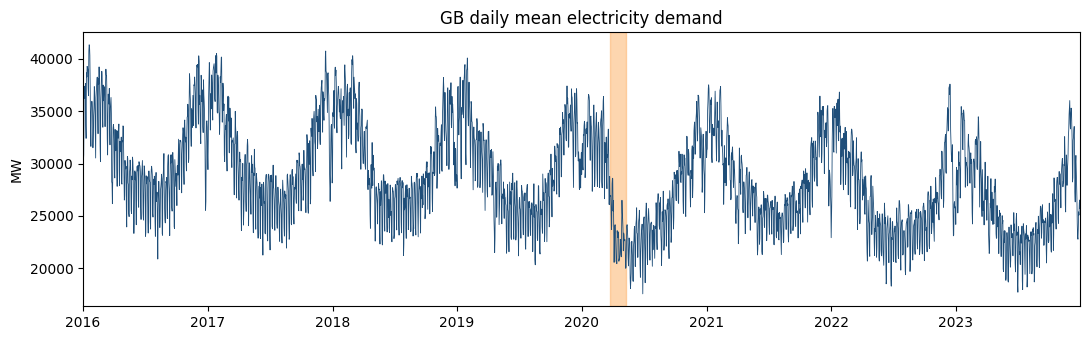

In [3]:
# Daily mean demand. The annual saw-tooth is the seasonal cycle (winter peaks, summer troughs);
# the shaded band is the spring 2020 lockdown, when demand fell sharply.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(raw.index, raw["demand_mean"], linewidth=0.6, color="#1f4e79")
ax.axvspan(pd.Timestamp("2020-03-24"), pd.Timestamp("2020-05-10"), color="#fdae61", alpha=0.5)
ax.set_title("GB daily mean electricity demand")
ax.set_ylabel("MW")
ax.margins(x=0)
fig.tight_layout();

## Features and target

As in the finance notebook we predict the **next-day change** in demand rather than its level,
because the level is so persistent that a single lag would dominate and hide the other drivers.
The features are all known on day `t` and predict the demand move into day `t + 1`: today's
demand and its day-on-day change, the same-weekday value a week earlier, a weekend flag for the
weekly work cycle, two smooth terms for the annual cycle, and the day's embedded wind and solar
generation.

We use a weekend flag rather than a raw day-of-week number: the raw number would impose a false
ordering on the days, and the weekend flag is the clean way to give the model the weekly cycle.

In [4]:
df = pd.DataFrame(index=raw.index)
df["demand"] = raw["demand_mean"]
df["demand_lag7"] = raw["demand_mean"].shift(7)            # same weekday last week
df["demand_mom1"] = raw["demand_mean"].diff(1)             # yesterday to today
df["is_weekend"] = (raw.index.dayofweek >= 5).astype(int)  # the weekly work cycle
doy = raw.index.dayofyear
df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)           # annual cycle, as two smooth terms
df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
df["wind"] = raw["wind"]
df["solar"] = raw["solar"]

target = (raw["demand_mean"].shift(-1) - raw["demand_mean"]).rename("demand_chg")

model_data = df.join(target).dropna()  # the lag and the shift leave NaNs at the edges
X = model_data.drop(columns="demand_chg")
y = model_data["demand_chg"]
print("design matrix:", X.shape)
X.head()

design matrix: (2914, 8)


,demand,demand_lag7,demand_mom1,is_weekend,doy_sin,doy_cos,wind,solar
date,,,,,,,,
2016-01-08,37653.2,29360.0,1440.5,0,0.137185,0.990545,1079.2,369.1
2016-01-09,33690.6,30071.0,-3962.6,1,0.154204,0.988039,1356.9,146.0
2016-01-10,32404.7,30849.3,-1285.9,1,0.171177,0.985240,2016.4,344.4
2016-01-11,38662.3,36097.9,6257.6,0,0.188099,0.982150,966.0,214.9
2016-01-12,38279.1,37103.5,-383.2,0,0.204966,0.978769,1968.9,283.8


## Label the regimes by hand

Here we give the labels directly, one per row, which is the most general regime input the
package accepts. Each day is labelled by its season, and the spring 2020 strict-lockdown window
is relabelled as its own regime. `RegimeSHAPAnalyzer` takes this list as is.

In [5]:
season = {12: "winter", 1: "winter", 2: "winter",
          3: "spring", 4: "spring", 5: "spring",
          6: "summer", 7: "summer", 8: "summer",
          9: "autumn", 10: "autumn", 11: "autumn"}
labels = pd.Series([season[m] for m in X.index.month], index=X.index)

lockdown = (X.index >= "2020-03-24") & (X.index <= "2020-05-10")
labels[lockdown] = "2020 lockdown"

regimes = labels.tolist()
labels.value_counts()

summer           736
autumn           728
winter           714
spring           688
2020 lockdown     48
Name: count, dtype: int64

## Fit the model

A gradient-boosted tree again, fit on the whole history. As before this is a model to
interrogate, not a production demand forecast, and the in-sample fit just confirms it learned
something to explain.

In [6]:
model = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42
)
model.fit(X, y)
print(f"in-sample R^2: {model.score(X, y):.3f}")

in-sample R^2: 0.710


## Run the analysis

One difference from the finance run: we set `small_sample_threshold` to 200. The four seasonal
regimes each span hundreds of days across eight years, while the lockdown regime spans about
seven weeks, so this threshold flags any regime much smaller than a full season, which here is
only the lockdown. This is a dataset-relative choice, not a claim that seven weeks is too little
data. It simply marks that a ranking estimated from seven weeks carries more uncertainty than
one estimated from years, which we quantify with bootstrap intervals further down.

In [7]:
analyzer = RegimeSHAPAnalyzer(model, X, regimes, small_sample_threshold=200)
analyzer.global_importance().round(1)

is_weekend     1163.800049
demand_mom1     727.299988
solar           592.700012
demand_lag7     430.299988
wind            426.700012
demand          286.000000
doy_cos         241.199997
doy_sin         212.699997
Name: mean_abs_shap, dtype: float32

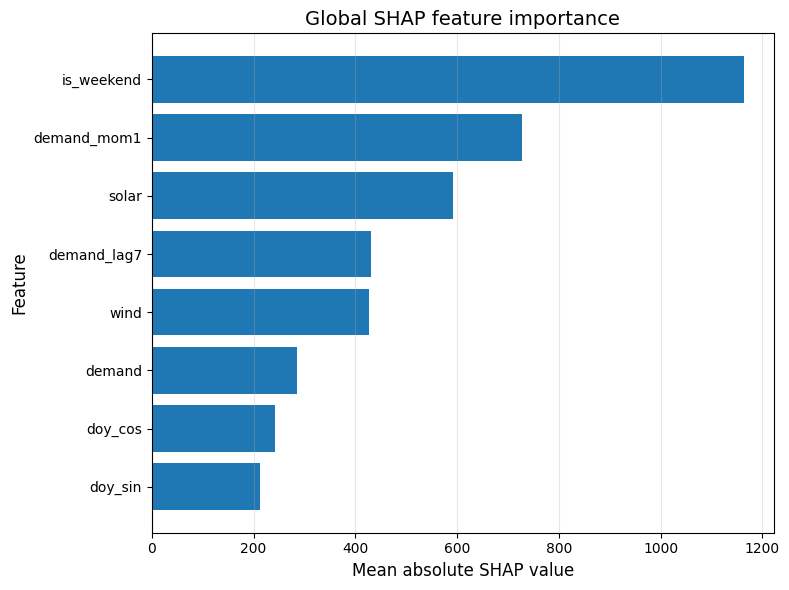

In [8]:
analyzer.plot_global();

## Per-regime rankings

The seasons put their weight in broadly the same places, which is already a hint at the answer.

In [9]:
analyzer.per_regime_rankings()

,winter,spring,summer,autumn,2020 lockdown
demand,6.0,7.0,7.0,7.0,5.0
demand_lag7,4.0,5.0,4.0,5.0,3.0
demand_mom1,2.0,2.0,2.0,2.0,4.0
is_weekend,1.0,1.0,1.0,1.0,1.0
doy_sin,8.0,6.0,8.0,6.0,7.0
doy_cos,7.0,8.0,6.0,8.0,8.0
wind,5.0,4.0,5.0,4.0,6.0
solar,3.0,3.0,3.0,3.0,2.0


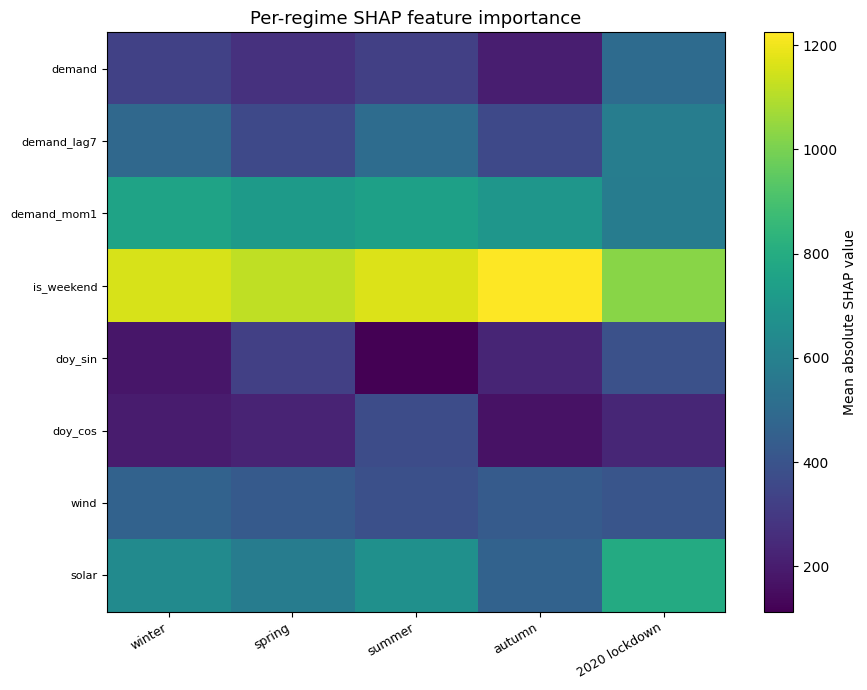

In [10]:
analyzer.plot_per_regime();

## Stability across regimes

Same reading as before: each cell is the Spearman rank correlation between two regimes'
importance rankings, and the Akoglu (2018) bands label it stable (rho above 0.6), moderately
stable (0.3 to 0.6), or unstable (0.3 or below).

In [11]:
analyzer.stability_matrix().round(3)

,winter,spring,summer,autumn,2020 lockdown
winter,1.000,0.905,0.976,0.905,0.881
spring,0.905,1.000,0.881,1.000,0.786
summer,0.976,0.881,1.000,0.881,0.810
autumn,0.905,1.000,0.881,1.000,0.786
2020 lockdown,0.881,0.786,0.810,0.786,1.000


In [12]:
analyzer.stability_classified()

,regime_a,regime_b,spearman_rho,band,involves_small_regime
0,winter,spring,0.904762,stable,False
1,winter,summer,0.976190,stable,False
2,winter,autumn,0.904762,stable,False
3,winter,2020 lockdown,0.880952,stable,True
4,spring,summer,0.880952,stable,False
5,spring,autumn,1.000000,stable,False
6,spring,2020 lockdown,0.785714,stable,True
7,summer,autumn,0.880952,stable,False
8,summer,2020 lockdown,0.809524,stable,True
9,autumn,2020 lockdown,0.785714,stable,True


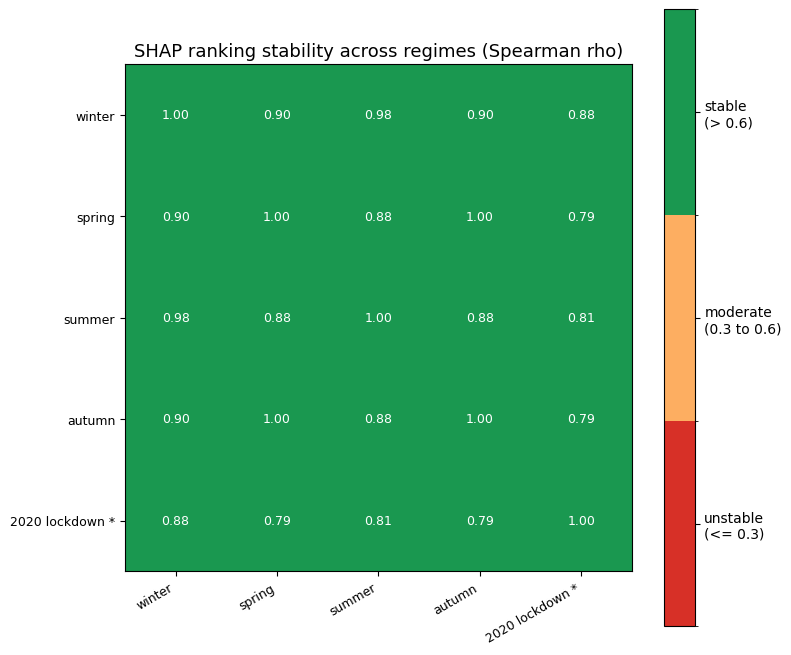

In [13]:
analyzer.plot_stability();

This is the opposite result to the finance notebook, and that is the point. The demand model's
drivers are **stable**: every pair sits in the stable band, and the four seasons agree very
closely (spring and autumn are effectively identical). The weekly work cycle and the day-on-day
momentum lead the ranking in every season. A demand model, unlike the crisis-sensitive
volatility model, rests on foundations that hold as the year turns.

The one regime that stands even slightly apart is the 2020 lockdown: its correlations with the
seasons (around 0.79 to 0.88) are the lowest in the matrix, which fits the history, since the
lockdown flattened the usual weekly and daily demand rhythm. Because that regime is short, we
should not read its exact numbers too literally, which is what the confidence intervals below
are for.

## The small regime, with bootstrap confidence intervals

Because the lockdown regime is flagged small, the analyzer can attach a bootstrap confidence
interval to each of its stability correlations. It resamples the 48 lockdown days with
replacement, recomputes the ranking each time, and reports the range the correlation takes. The
intervals are wide, which is the honest message: a ranking from seven weeks of data is more
uncertain than one from years, so the point estimates above should be read as indicative, not
exact.

In [14]:
analyzer.sample_sizes()

,regime,n_observations,small_sample
0,winter,714,False
1,spring,688,False
2,summer,736,False
3,autumn,728,False
4,2020 lockdown,48,True


In [15]:
analyzer.bootstrap_cis(n_bootstrap=500)

,regime_a,regime_b,ci_lower,ci_upper,effective_n
0,winter,2020 lockdown,0.714286,0.952381,48
1,spring,2020 lockdown,0.619048,0.928571,48
2,summer,2020 lockdown,0.595238,0.880952,48
3,autumn,2020 lockdown,0.619048,0.928571,48


## Save the results

The same export helpers as the finance notebook.

In [16]:
import tempfile
from pathlib import Path

out_dir = Path(tempfile.mkdtemp())
paths = analyzer.save_csv(out_dir)
html = analyzer.to_html(title="GB electricity demand: SHAP stability across seasons")
print(f"wrote {len(paths)} CSV tables and a {len(html):,}-character HTML report to {out_dir}")

wrote 6 CSV tables and a 7,890-character HTML report to /var/folders/0m/7cd4sg3s2h9_28bz90nk68wr0000gn/T/tmp3g_pwgsk


## Adapt this to your own data

Between the two notebooks you have now seen both regime-input paths and both kinds of result:

- finance: regimes found from the data with `detect_breaks`, and drivers that **change** in a crisis;
- energy: regimes **labelled by hand**, a small regime read with bootstrap intervals, and drivers that **hold** across seasons.

The recipe is the same either way. Build a feature matrix and target, fit any
`shap.TreeExplainer`-compatible model, attach one regime label per row, and let
`RegimeSHAPAnalyzer` tell you whether the model's reasoning is stable where it needs to be.